# Predict Customer Churn — Exploratory Data Analysis

**Competition:** [Kaggle Playground Series S6E3](https://www.kaggle.com/competitions/playground-series-s6e3/overview)  
**Author:** Denis Lazurenko  
**Role:** Data Analyst — EDA & Feature Engineering  

---

## Objective

Predict which telecom customers are likely to churn (cancel their subscription). This notebook covers the full EDA pipeline: data cleaning, demographic profiling, behavioral analysis, and feature engineering — all grounded in business context.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Quality Check](#2-data-quality-check)
3. [Demographic Analysis](#3-demographic-analysis)
4. [Behavioral & Financial Analysis](#4-behavioral--financial-analysis)
5. [Service Usage Analysis](#5-service-usage-analysis)
6. [Feature Engineering](#6-feature-engineering)
7. [Key Findings](#7-key-findings)
8. [Appendix — What Could Be Done Next](#8-appendix--what-could-be-done-next)

## 1. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [5]:
# Update paths as needed
train = pd.read_csv(r'C:\projects\Hackathon\Predict_Customer_Churn\data\raw\train.csv')
test  = pd.read_csv(r'C:\projects\Hackathon\Predict_Customer_Churn\data\raw\test.csv')
sample_submission = pd.read_csv(r'C:\projects\Hackathon\Predict_Customer_Churn\data\raw\sample_submission.csv')

# Work on copies to keep raw data intact
df = train.copy(deep=True)
df_test = test.copy(deep=True)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')

Train shape : (594194, 21)
Test shape  : (254655, 20)


## 2. Data Quality Check

In [6]:
def quick_eda(df):
    """Full dataset diagnostic. Run this first."""
    print('=' * 55)
    print(f'  Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Duplicates : {df.duplicated().sum()}')
    print(f'  Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    print('=' * 55)

    info = pd.DataFrame({
        'dtype'    : df.dtypes,
        'non-null' : df.count(),
        'missing'  : df.isnull().sum(),
        'missing%' : (df.isnull().mean() * 100).round(2),
        'unique'   : df.nunique()
    })
    return info

quick_eda(df)

  Shape      : 594,194 rows x 21 columns
  Duplicates : 0
  Memory     : 546.2 MB


,dtype,non-null,missing,missing%,unique
id,int64,594194,0,0.000,594194
gender,object,594194,0,0.000,2
SeniorCitizen,int64,594194,0,0.000,2
Partner,object,594194,0,0.000,2
Dependents,object,594194,0,0.000,2
tenure,int64,594194,0,0.000,72
PhoneService,object,594194,0,0.000,2
MultipleLines,object,594194,0,0.000,3
InternetService,object,594194,0,0.000,3
OnlineSecurity,object,594194,0,0.000,3


In [7]:
# TotalCharges contains whitespace strings — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Verify unique values in key categorical columns
for col in ['InternetService', 'Contract', 'PaymentMethod']:
    print(f'{col}: {df[col].unique()}')

InternetService: ['DSL' 'Fiber optic' 'No']
Contract: ['One year' 'Two year' 'Month-to-month']
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']


In [8]:
# Quick look at the data
df.sample(5, random_state=RANDOM_STATE)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
392211,392211,Female,0,Yes,No,71,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.450,6293.450,No
370260,370260,Female,0,Yes,No,44,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,No,Mailed check,75.550,3888.600,No
65386,65386,Male,0,Yes,Yes,53,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.750,1077.750,No
526552,526552,Male,0,Yes,Yes,52,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.200,2719.200,No
3996,3996,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,44.700,44.700,Yes


### Target Distribution

The dataset is imbalanced — approximately 22.5% of customers churned. This will need to be addressed in modeling (e.g., via `class_weight='balanced'`).

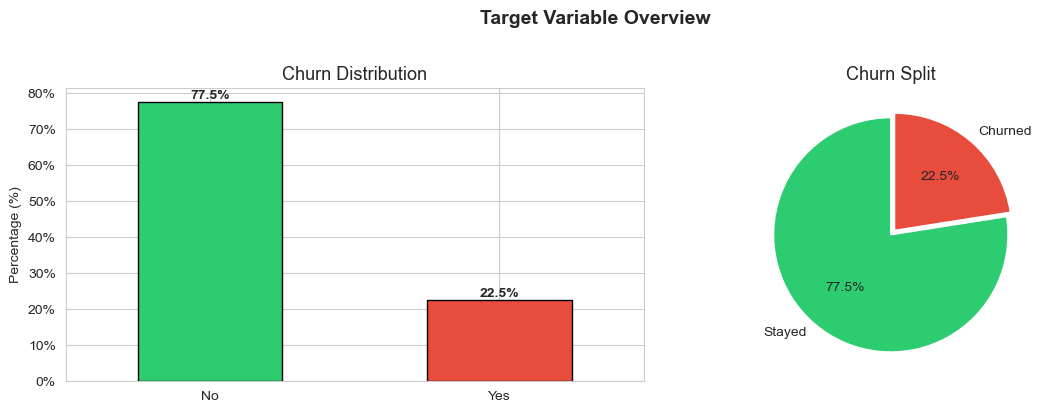

Overall churn rate: 22.5%
Class imbalance ratio: 1 churned for every 3.4 retained


In [9]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_rate.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Percentage (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(churn_rate.values, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Churn Split', fontsize=13)

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Overall churn rate: {churn_rate["Yes"]:.1f}%')
print(f'Class imbalance ratio: 1 churned for every {churn_rate["No"]/churn_rate["Yes"]:.1f} retained')

## 3. Demographic Analysis

### 3.1 Senior Citizens — The High-Risk Segment

In [10]:
# Split into two segments
senior_nat = df.loc[df['SeniorCitizen'] == 1]
senior_nat_count = len(senior_nat)

other_nat = df.loc[df['SeniorCitizen'] == 0]
other_nat_count = len(other_nat)

# Share of seniors in the customer base
senior_percents = (df['SeniorCitizen'].value_counts(normalize=True) * 100).reset_index()
senior_percents.columns = ['Segment', 'Share (%)']
senior_percents['Segment'] = senior_percents['Segment'].map({0: 'Younger', 1: 'Senior'})

print('Customer base composition:')
print(senior_percents.to_string(index=False))

Customer base composition:
Segment  Share (%)
Younger     88.590
 Senior     11.410


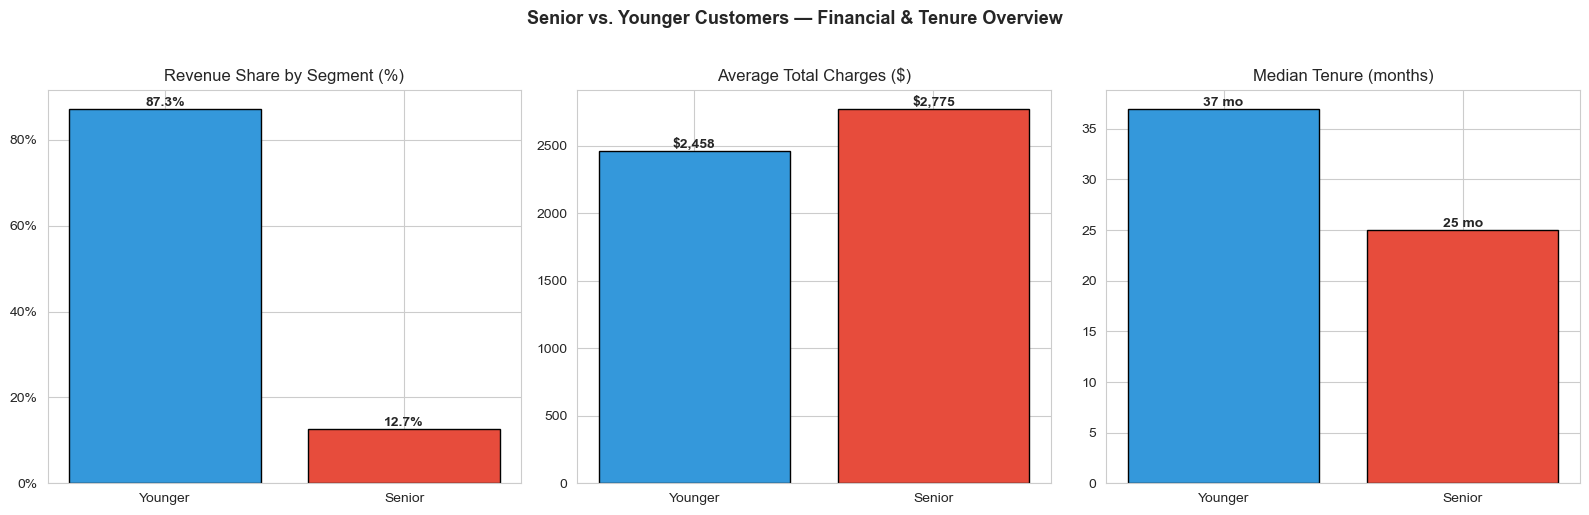

Key observation: seniors represent ~11% of the base but contribute ~13% of revenue.
Their average charges are higher — yet they churn far more often.


In [11]:
# Revenue contribution and average spend
charges_nat  = df.groupby('SeniorCitizen')['TotalCharges'].sum().reset_index()
charges_perc = (df.groupby('SeniorCitizen')['TotalCharges'].sum() / df['TotalCharges'].sum() * 100).reset_index()
charges_avg  = df.groupby('SeniorCitizen')['TotalCharges'].mean().reset_index()
tenure_stats = df.groupby('SeniorCitizen')['tenure'].agg(['min', 'median', 'max']).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ['Younger', 'Senior']
colors = ['#3498db', '#e74c3c']

axes[0].bar(labels, charges_perc['TotalCharges'], color=colors, edgecolor='black')
axes[0].set_title('Revenue Share by Segment (%)', fontsize=12)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].bar(labels, charges_avg['TotalCharges'], color=colors, edgecolor='black')
axes[1].set_title('Average Total Charges ($)', fontsize=12)
for p in axes[1].patches:
    axes[1].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[2].bar(labels, tenure_stats['median'], color=colors, edgecolor='black')
axes[2].set_title('Median Tenure (months)', fontsize=12)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0f} mo', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Senior vs. Younger Customers — Financial & Tenure Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Key observation: seniors represent ~11% of the base but contribute ~13% of revenue.')
print('Their average charges are higher — yet they churn far more often.')

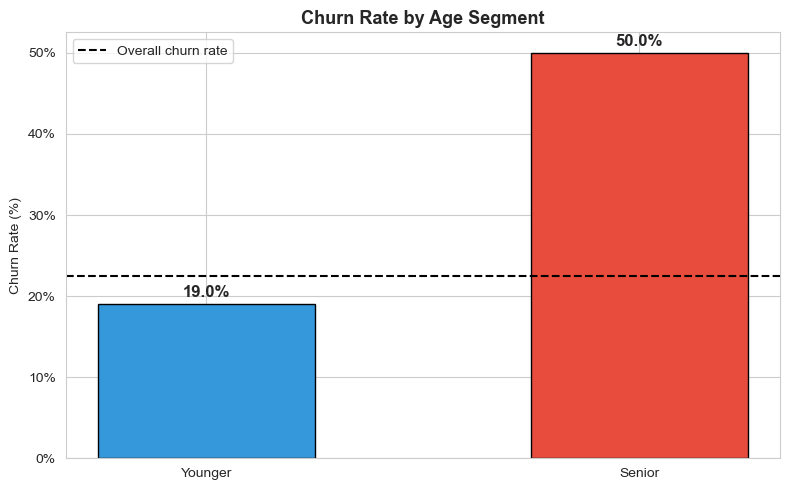

Senior churn rate : 50.0%
Younger churn rate: 19.0%
Seniors churn 2.6x more often than younger customers.


In [12]:
# Churn rates by segment
senior_lefts_perc = (df.loc[(df['Churn'] == 'Yes') & (df['SeniorCitizen'] == 1)].shape[0] * 100) / \
                     df.loc[df['SeniorCitizen'] == 1].shape[0]

other_lefts_perc  = (df.loc[(df['Churn'] == 'Yes') & (df['SeniorCitizen'] == 0)].shape[0] * 100) / \
                     df.loc[df['SeniorCitizen'] == 0].shape[0]

fig, ax = plt.subplots(figsize=(8, 5))
segments = ['Younger', 'Senior']
churn_rates = [other_lefts_perc, senior_lefts_perc]
bars = ax.bar(segments, churn_rates, color=['#3498db', '#e74c3c'], edgecolor='black', width=0.5)
ax.axhline(y=df['Churn'].value_counts(normalize=True)['Yes'] * 100,
           color='black', linestyle='--', linewidth=1.5, label='Overall churn rate')
ax.set_title('Churn Rate by Age Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
for bar, val in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Senior churn rate : {senior_lefts_perc:.1f}%')
print(f'Younger churn rate: {other_lefts_perc:.1f}%')
print(f'Seniors churn {senior_lefts_perc / other_lefts_perc:.1f}x more often than younger customers.')

### 3.2 Gender — Does It Matter?

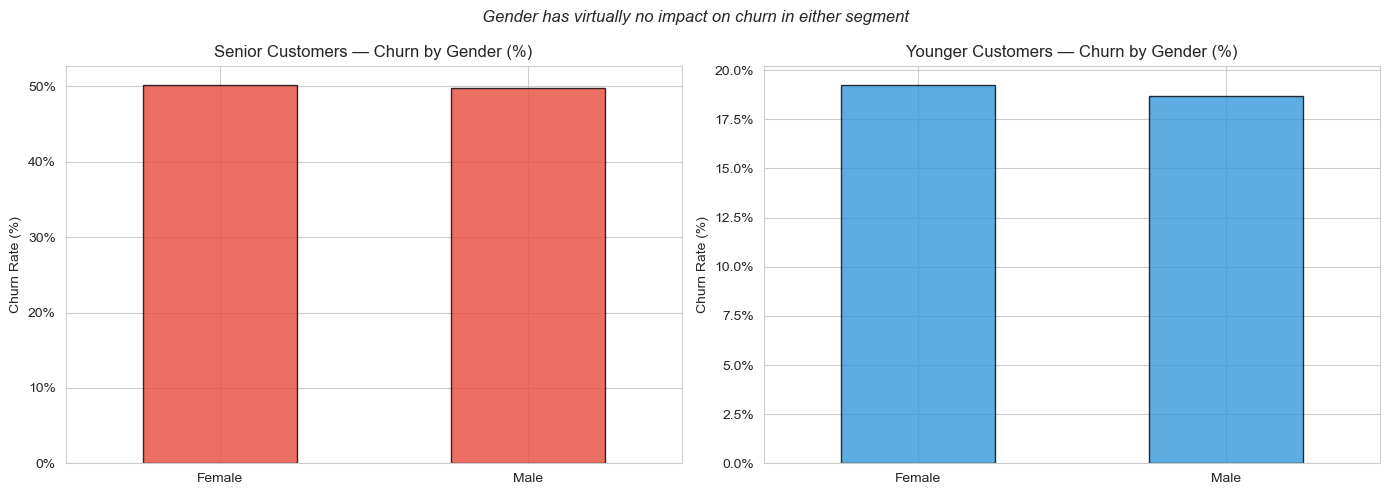

In [13]:
# Churn split by gender, for each segment
senior_gender_churn = df[df['SeniorCitizen'] == 1].groupby(['gender', 'Churn']).size().unstack()
senior_gender_churn_perc = senior_gender_churn.div(senior_gender_churn.sum(axis=1), axis=0) * 100

other_gender_churn = df[df['SeniorCitizen'] == 0].groupby(['gender', 'Churn']).size().unstack()
other_gender_churn_perc = other_gender_churn.div(other_gender_churn.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

senior_gender_churn_perc['Yes'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#e74c3c'],
                                      edgecolor='black', alpha=0.8)
axes[0].set_title('Senior Customers — Churn by Gender (%)', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

other_gender_churn_perc['Yes'].plot(kind='bar', ax=axes[1], color=['#3498db', '#3498db'],
                                     edgecolor='black', alpha=0.8)
axes[1].set_title('Younger Customers — Churn by Gender (%)', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Gender has virtually no impact on churn in either segment', fontsize=12, style='italic')
plt.tight_layout()
plt.show()

> **Finding:** Gender is evenly distributed (~50/50) and shows no meaningful difference in churn rates within either segment. It will not be a useful predictive feature.

### 3.3 Family Status — The Retention Anchor

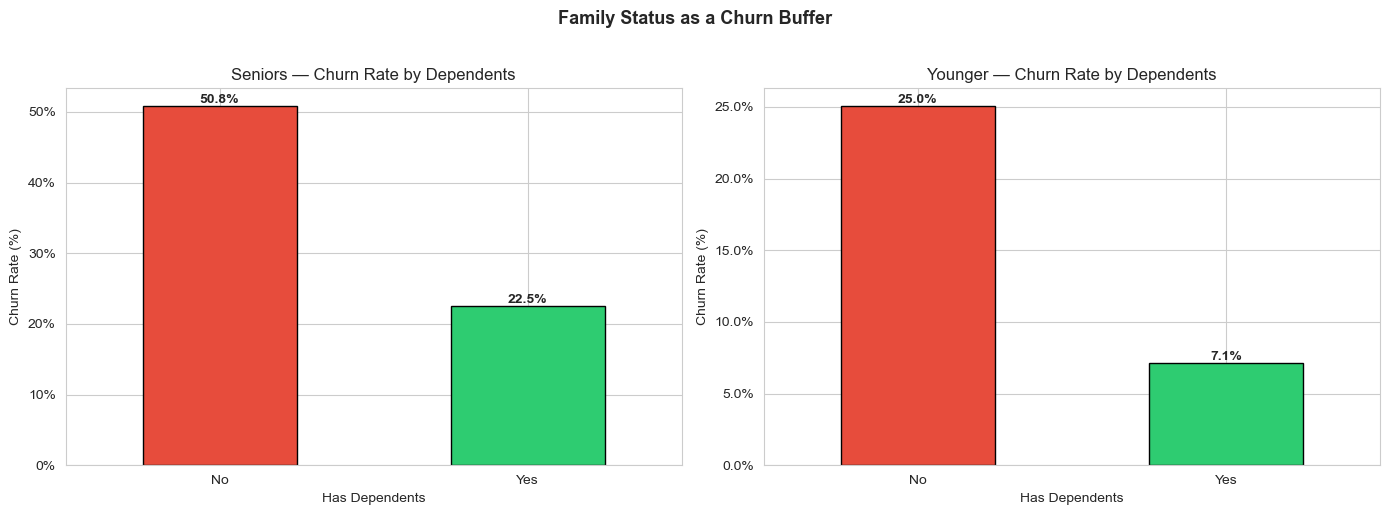

In [14]:
# Impact of dependents on churn — seniors vs. younger
senior_churn_diff = df[df['SeniorCitizen'] == 1].groupby(['Dependents', 'Churn']).size().unstack()
senior_churn_diff_perc = senior_churn_diff.div(senior_churn_diff.sum(axis=1), axis=0) * 100

other_churn_diff = df[df['SeniorCitizen'] == 0].groupby(['Dependents', 'Churn']).size().unstack()
other_churn_diff_perc = other_churn_diff.div(other_churn_diff.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

senior_churn_diff_perc['Yes'].plot(kind='bar', ax=axes[0],
                                    color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Seniors — Churn Rate by Dependents', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Has Dependents')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

other_churn_diff_perc['Yes'].plot(kind='bar', ax=axes[1],
                                   color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Younger — Churn Rate by Dependents', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Has Dependents')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Family Status as a Churn Buffer', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

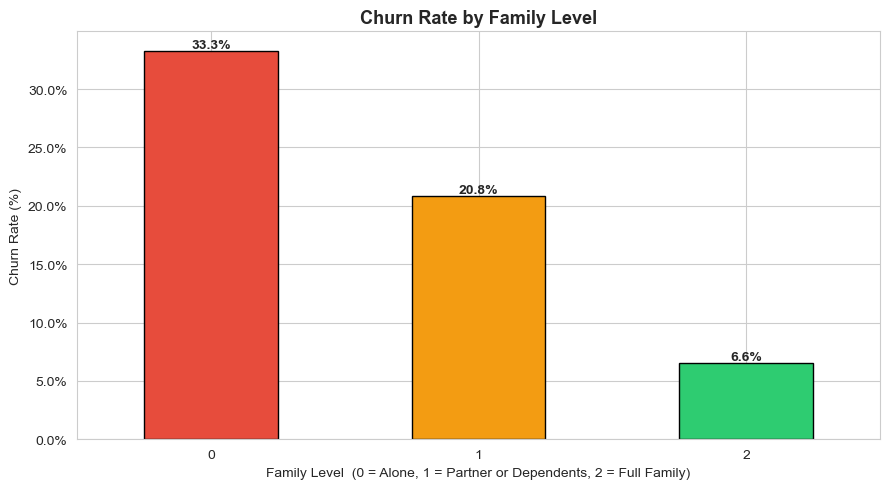

Key observation:
family_level
0   33.285
1   20.818
2    6.579


In [15]:
# Family level composite score: 0 = alone, 1 = partner or dependents, 2 = full family
def get_family_level(row):
    score = 0
    if row['Partner'] == 'Yes': score += 1
    if row['Dependents'] == 'Yes': score += 1
    return score

df['family_level'] = df.apply(get_family_level, axis=1)

# Churn rate by family level
family_churn = pd.crosstab(df['family_level'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(9, 5))
family_churn['Yes'].plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'],
                          edgecolor='black', width=0.5)
ax.set_title('Churn Rate by Family Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Family Level  (0 = Alone, 1 = Partner or Dependents, 2 = Full Family)')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observation:')
print(family_churn['Yes'].to_string())

## 4. Behavioral & Financial Analysis

### 4.1 Tenure — The Critical First Year

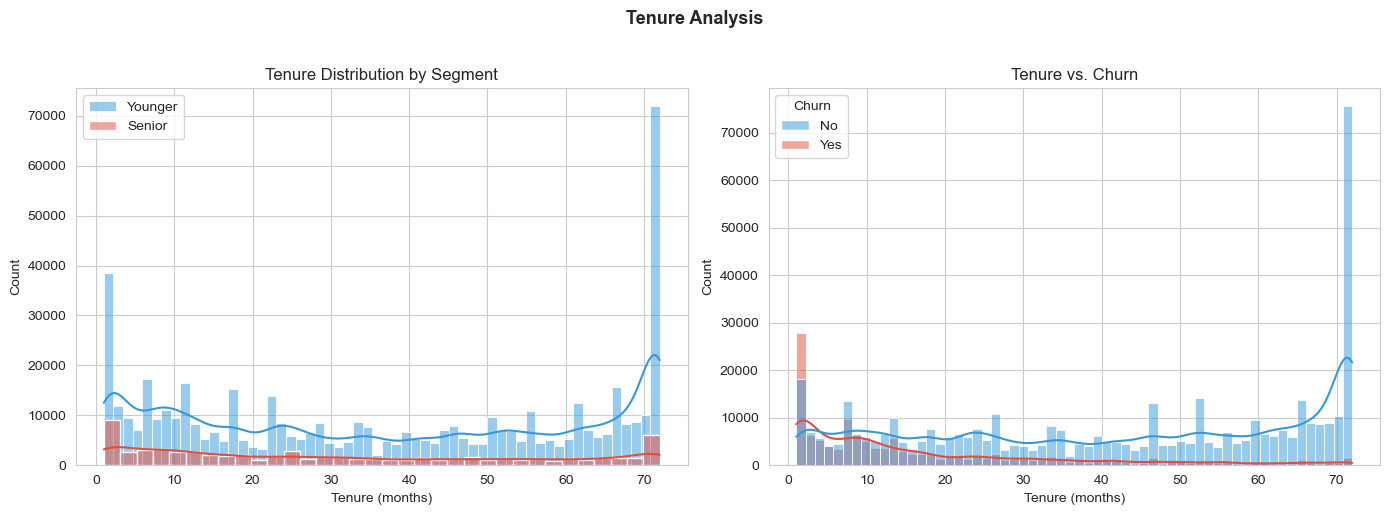

In [16]:
# Tenure distribution: seniors vs. younger
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(other_nat['tenure'], color='#3498db', label='Younger', kde=True, ax=axes[0])
sns.histplot(senior_nat['tenure'], color='#e74c3c', label='Senior', kde=True, ax=axes[0])
axes[0].set_title('Tenure Distribution by Segment', fontsize=12)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Tenure vs. churn
sns.histplot(data=df, x='tenure', hue='Churn',
             palette={'No': '#3498db', 'Yes': '#e74c3c'}, kde=True, ax=axes[1])
axes[1].set_title('Tenure vs. Churn', fontsize=12)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')

plt.suptitle('Tenure Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

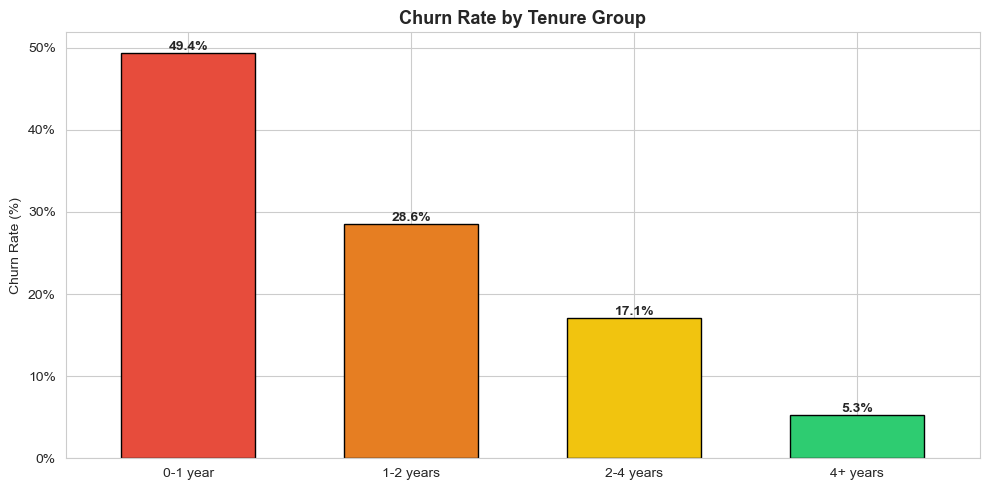

tenure_group
0-1 year    49.395
1-2 years   28.578
2-4 years   17.066
4+ years     5.270

The first 12 months are the "death zone" — highest churn risk.


In [17]:
# Churn rate by tenure group
def tenure_group(t):
    if t <= 12:
        return '0-1 year'
    elif t <= 24:
        return '1-2 years'
    elif t <= 48:
        return '2-4 years'
    else:
        return '4+ years'

df['tenure_group'] = df['tenure'].apply(tenure_group)

tenure_churn = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack() * 100
order = ['0-1 year', '1-2 years', '2-4 years', '4+ years']
tenure_churn = tenure_churn.reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
tenure_churn['Yes'].plot(kind='bar', ax=ax,
                          color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
                          edgecolor='black', width=0.6)
ax.set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(tenure_churn['Yes'].to_string())
print('\nThe first 12 months are the "death zone" — highest churn risk.')

### 4.2 Monthly Charges — The Price Signal

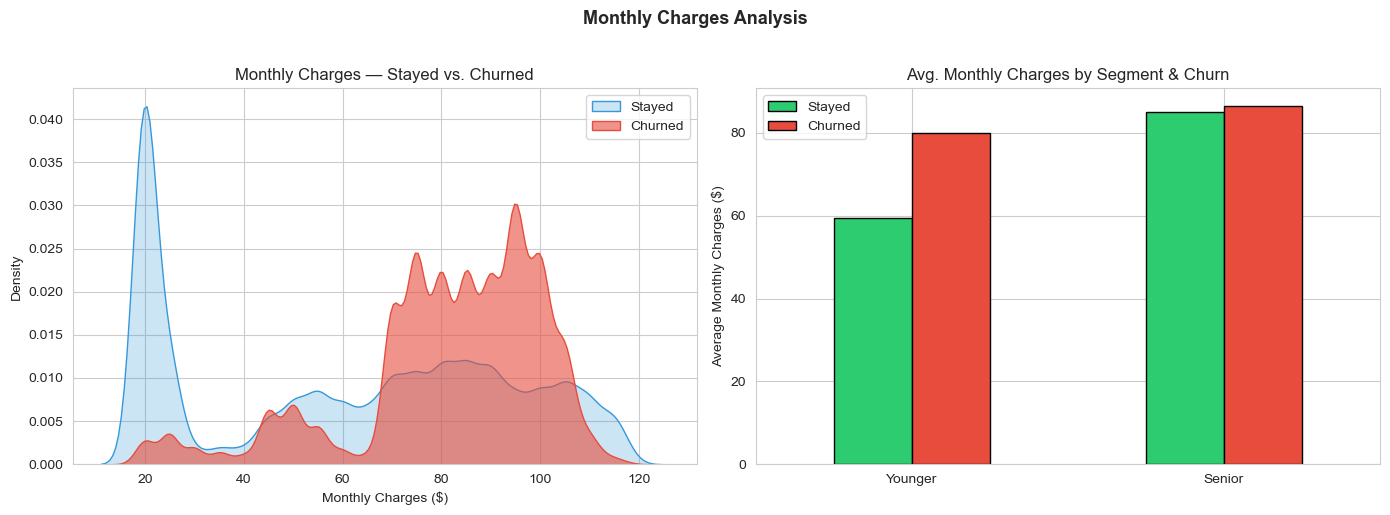

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='Stayed',
            fill=True, color='#3498db', ax=axes[0])
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Churned',
            fill=True, color='#e74c3c', alpha=0.6, ax=axes[0])
axes[0].set_title('Monthly Charges — Stayed vs. Churned', fontsize=12)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Average monthly charges by segment and churn
report2 = df.groupby(['SeniorCitizen', 'Churn'])['MonthlyCharges'].mean().unstack()
report2.index = ['Younger', 'Senior']
report2.plot(kind='bar', ax=axes[1],
             color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Avg. Monthly Charges by Segment & Churn', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Monthly Charges ($)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Stayed', 'Churned'])

plt.suptitle('Monthly Charges Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

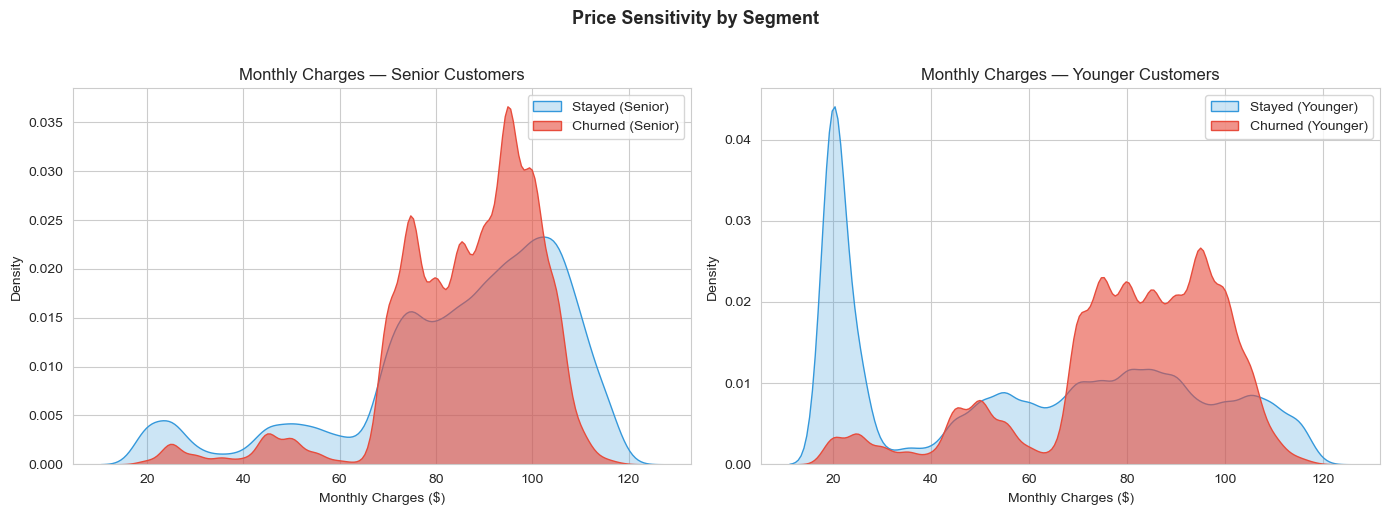

In [19]:
# Monthly charges distribution: seniors vs. younger, by churn status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seniors = df[df['SeniorCitizen'] == 1]
others  = df[df['SeniorCitizen'] == 0]

sns.kdeplot(data=seniors[seniors['Churn'] == 'No'], x='MonthlyCharges',
            label='Stayed (Senior)', fill=True, color='#3498db', ax=axes[0])
sns.kdeplot(data=seniors[seniors['Churn'] == 'Yes'], x='MonthlyCharges',
            label='Churned (Senior)', fill=True, color='#e74c3c', alpha=0.6, ax=axes[0])
axes[0].set_title('Monthly Charges — Senior Customers', fontsize=12)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

sns.kdeplot(data=others[others['Churn'] == 'No'], x='MonthlyCharges',
            label='Stayed (Younger)', fill=True, color='#3498db', ax=axes[1])
sns.kdeplot(data=others[others['Churn'] == 'Yes'], x='MonthlyCharges',
            label='Churned (Younger)', fill=True, color='#e74c3c', alpha=0.6, ax=axes[1])
axes[1].set_title('Monthly Charges — Younger Customers', fontsize=12)
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()

plt.suptitle('Price Sensitivity by Segment', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Contract Type & Payment Method — The Retention Levers

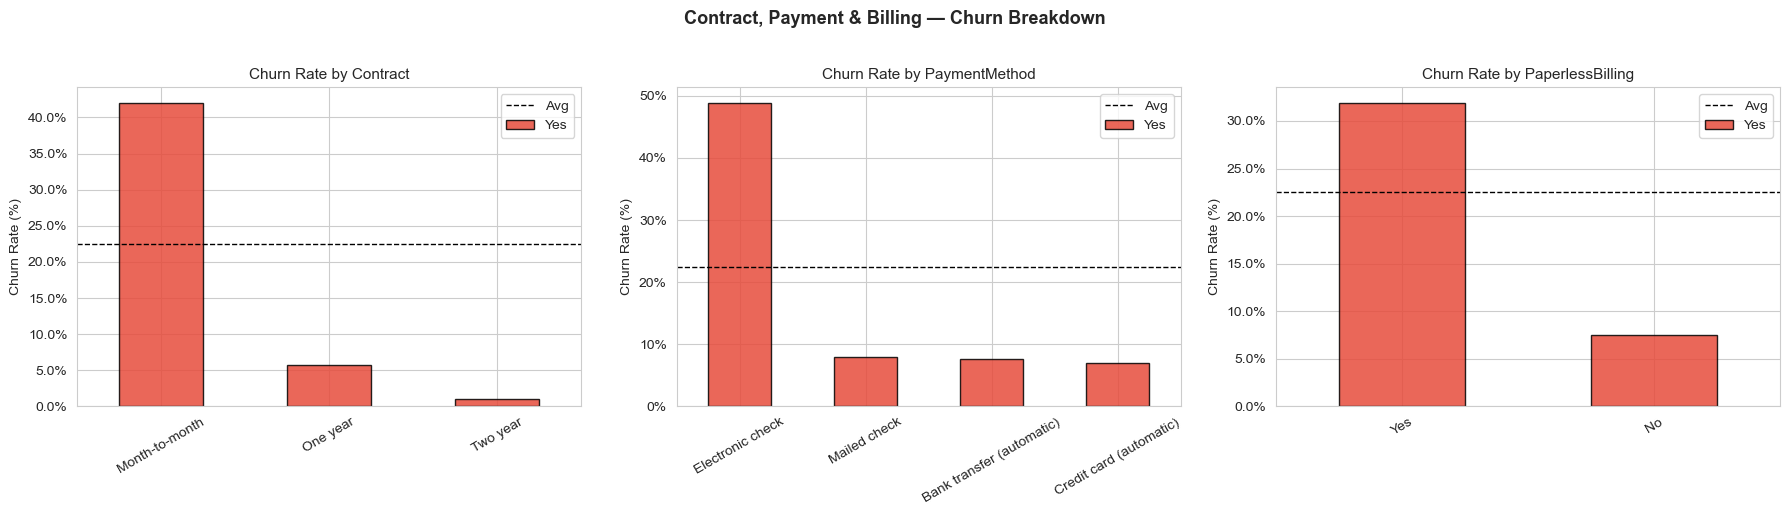

In [20]:
def get_churn_report(dataframe, column):
    """Returns churn rate breakdown for a given column."""
    return dataframe.groupby(column)['Churn'].value_counts(normalize=True).unstack() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols_to_check = ['Contract', 'PaymentMethod', 'PaperlessBilling']

for ax, col in zip(axes, cols_to_check):
    report = get_churn_report(df, col)
    report['Yes'].sort_values(ascending=False).plot(
        kind='bar', ax=ax, color='#e74c3c', edgecolor='black', alpha=0.85
    )
    ax.set_title(f'Churn Rate by {col}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.axhline(y=df['Churn'].value_counts(normalize=True)['Yes'] * 100,
               color='black', linestyle='--', linewidth=1, label='Avg')
    ax.legend()

plt.suptitle('Contract, Payment & Billing — Churn Breakdown', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Same analysis focused on senior customers
final_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']
print('--- Senior Customers: Churn by Contract & Payment ---')
for col in final_cols:
    print(f'\n{col}:')
    print(get_churn_report(seniors, col)['Yes'].sort_values(ascending=False).round(1).to_string())

--- Senior Customers: Churn by Contract & Payment ---

Contract:
Contract
Month-to-month   61.100
One year         15.600
Two year          3.900

PaymentMethod:
PaymentMethod
Electronic check            62.600
Mailed check                37.800
Bank transfer (automatic)   20.400
Credit card (automatic)     18.600

PaperlessBilling:
PaperlessBilling
Yes   52.800
No    28.700


### 4.4 Monthly Charges × Internet Service × Age — The Fiber Optic Trap

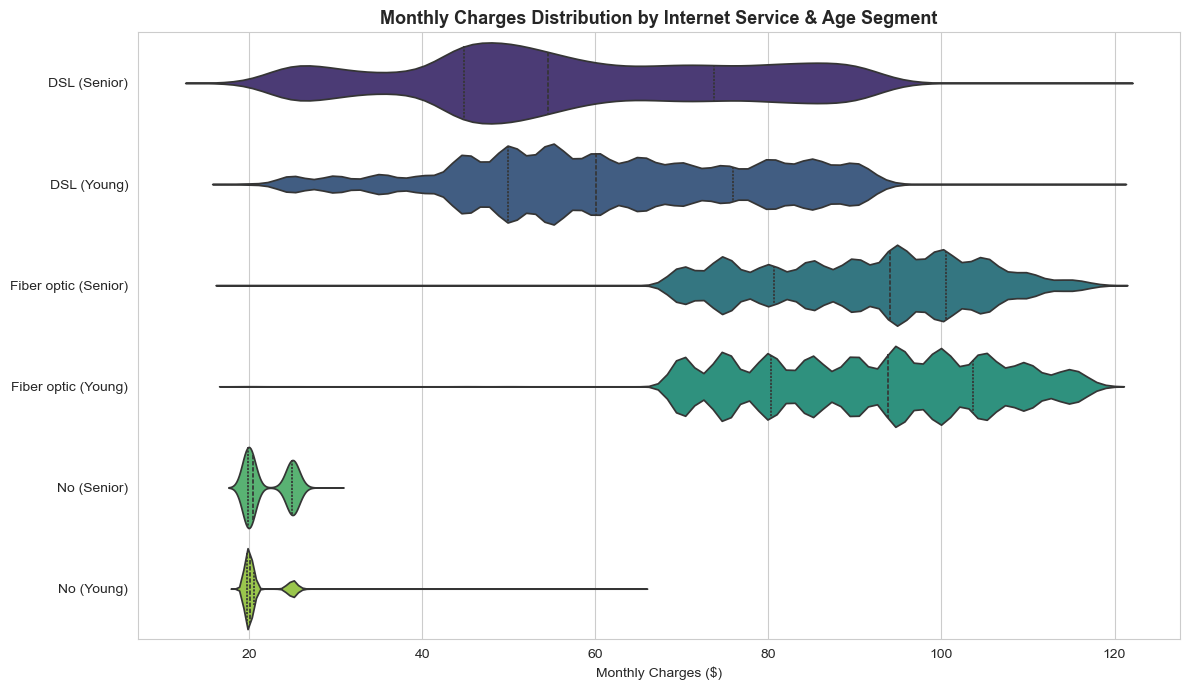

In [22]:
# Violin plot: monthly charges by internet service type and age segment
df_plot = df.copy()
df_plot['Group'] = df_plot['InternetService'] + ' (' + \
                   df_plot['SeniorCitizen'].map({1: 'Senior', 0: 'Young'}) + ')'

plt.figure(figsize=(12, 7))
order = sorted(df_plot['Group'].unique())
sns.violinplot(data=df_plot, y='Group', x='MonthlyCharges',
               order=order, palette='viridis', inner='quartile')
plt.title('Monthly Charges Distribution by Internet Service & Age Segment',
          fontsize=13, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Service Usage Analysis

### 5.1 Services Adoption by Segment

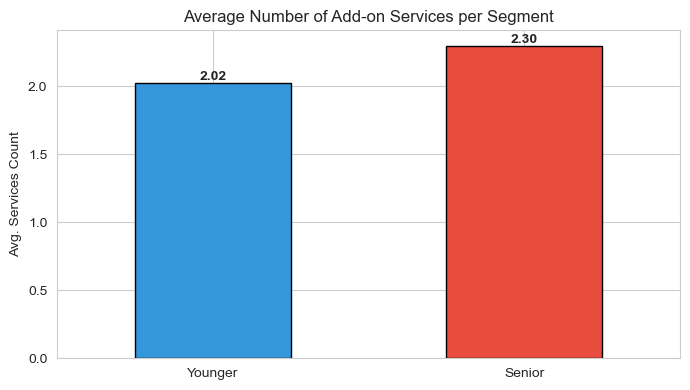

In [23]:
# Average number of add-on services per segment
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
df['services_count'] = (df[services] == 'Yes').sum(axis=1)

avg_services = df.groupby('SeniorCitizen')['services_count'].mean()
avg_services.index = ['Younger', 'Senior']

fig, ax = plt.subplots(figsize=(7, 4))
avg_services.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black', width=0.5)
ax.set_title('Average Number of Add-on Services per Segment', fontsize=12)
ax.set_ylabel('Avg. Services Count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

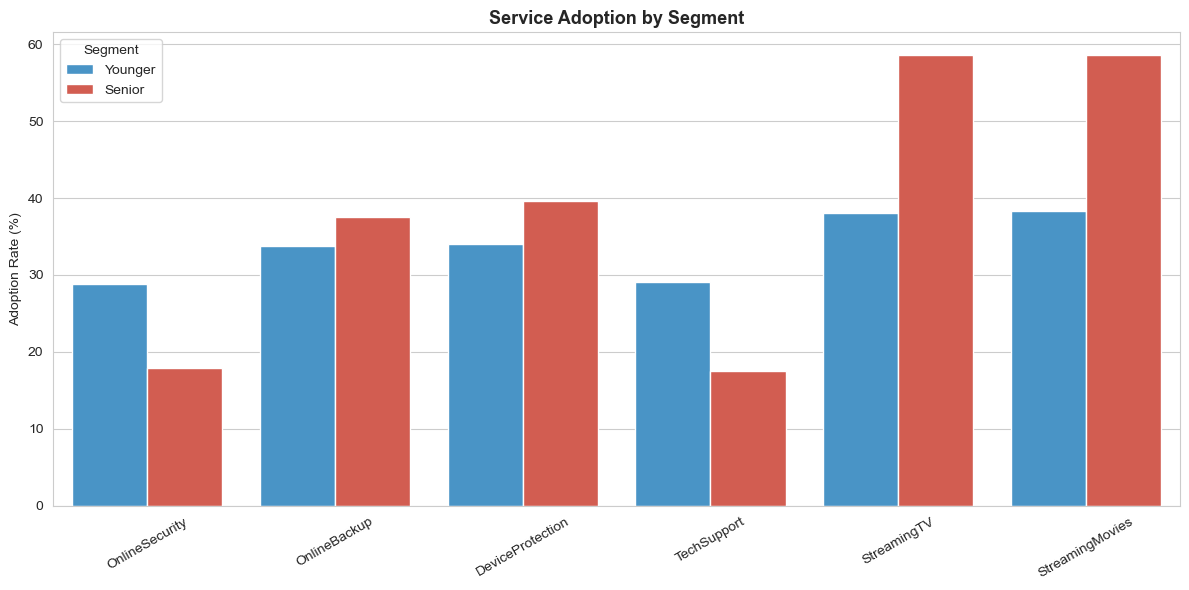

In [24]:
# Service adoption comparison: seniors vs. younger
comparison = []
for s in services:
    for status in [0, 1]:
        label = 'Senior' if status == 1 else 'Younger'
        pct = (df[df['SeniorCitizen'] == status][s] == 'Yes').mean() * 100
        comparison.append({'Service': s, 'Segment': label, 'Adoption (%)': pct})

comp_df = pd.DataFrame(comparison)

plt.figure(figsize=(12, 6))
sns.barplot(data=comp_df, x='Service', y='Adoption (%)', hue='Segment',
            palette={'Younger': '#3498db', 'Senior': '#e74c3c'})
plt.title('Service Adoption by Segment', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.xticks(rotation=30)
plt.ylabel('Adoption Rate (%)')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

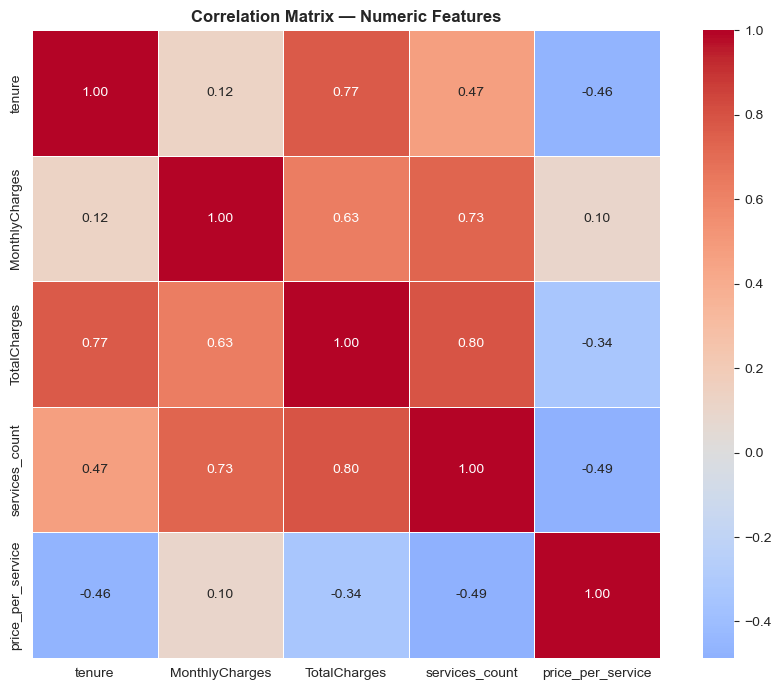

Correlation between (tenure × MonthlyCharges) and actual TotalCharges: 0.9921
High correlation confirms TotalCharges is redundant — we will drop it in modeling.


In [25]:
# Correlation heatmap: numeric features
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

if 'services_count' not in df.columns:
    df['services_count'] = (df[services] == 'Yes').sum(axis=1)

df['price_per_service'] = df['MonthlyCharges'] / (df['services_count'] + 1)
df['Expected_Total'] = df['tenure'] * df['MonthlyCharges']

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'services_count', 'price_per_service']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

formula_corr = df['Expected_Total'].corr(df['TotalCharges'])
print(f'Correlation between (tenure × MonthlyCharges) and actual TotalCharges: {formula_corr:.4f}')
print('High correlation confirms TotalCharges is redundant — we will drop it in modeling.')

## 6. Feature Engineering

Based on the EDA insights, the following features were engineered to encode domain knowledge into the model.

> **Note:** This section bridges EDA and ML. Feature selection and validation are covered in the ML notebook.

In [26]:
ml_ready = df.copy()

# 1. Technical risk: Fiber Optic without tech support
#    Hypothesis: Fiber customers paying a premium but not getting support are prone to leave
ml_ready['no_help_fiber'] = ((ml_ready['InternetService'] == 'Fiber optic') &
                              (ml_ready['TechSupport'] == 'No')).astype(int)

# 2. Financial risk trigger: Senior + Electronic check + Month-to-month
#    Hypothesis: This combination represents the highest-risk customer profile
ml_ready['senior_churn_trigger'] = ((ml_ready['SeniorCitizen'] == 1) &
                                     (ml_ready['PaymentMethod'] == 'Electronic check') &
                                     (ml_ready['Contract'] == 'Month-to-month')).astype(int)

# 3. Auto-payment flag: reduces friction, correlated with retention
ml_ready['is_auto_pay'] = ml_ready['PaymentMethod'].str.contains('automatic').astype(int)

# 4. Price per service: captures hidden dissatisfaction — paying a lot for few services
#    Adding 1 to denominator avoids division by zero
ml_ready['price_per_service'] = ml_ready['MonthlyCharges'] / (ml_ready['services_count'] + 1)

# 5. Family level: social stability proxy
ml_ready['family_level'] = (ml_ready['Partner'] == 'Yes').astype(int) + \
                            (ml_ready['Dependents'] == 'Yes').astype(int)

# Clean up
ml_ready['TotalCharges'] = pd.to_numeric(ml_ready['TotalCharges'], errors='coerce').fillna(0)
if 'TotalCharges' in ml_ready.columns:
    ml_ready.drop(columns=['TotalCharges'], inplace=True)  # multicollinear with tenure

cols_to_drop = ['id', 'Expected_Total', 'tenure_group']
ml_ready.drop(columns=[c for c in cols_to_drop if c in ml_ready.columns], inplace=True)

print('--- Feature engineering complete ---')
print(f'New features: no_help_fiber, senior_churn_trigger, is_auto_pay, price_per_service, family_level')
print(f'Dataset shape: {ml_ready.shape}')
ml_ready[['no_help_fiber', 'senior_churn_trigger', 'is_auto_pay',
          'price_per_service', 'family_level']].head()

--- Feature engineering complete ---
New features: no_help_fiber, senior_churn_trigger, is_auto_pay, price_per_service, family_level
Dataset shape: (594194, 25)


,no_help_fiber,senior_churn_trigger,is_auto_pay,price_per_service,family_level
0,0,0,0,15.025,2
1,0,0,1,13.900,2
2,1,0,0,25.100,1
3,1,0,0,69.700,0
4,1,0,0,70.450,0


## 7. Key Findings

### Socio-Demographic

| Finding | Detail |
|---|---|
| **Senior churn rate is 2.6x higher** | 50% vs. 19% for younger customers |
| **Family as a retention anchor** | Customers with partner + dependents churn ~5x less |
| **Lone seniors are the highest-risk group** | 60%+ churn rate with no dependents |
| **Gender is irrelevant** | ~50/50 split, no meaningful churn difference |

### Financial & Contractual

| Finding | Detail |
|---|---|
| **Month-to-month contracts are the primary driver** | 61% churn vs. <5% on 2-year contracts |
| **Electronic check correlates with churn** | Manual friction + churn signal |
| **`price_per_service` reveals hidden dissatisfaction** | High spend on few services |
| **Paperless billing paradox** | Higher churn despite being digital-native |

### Technical & Behavioral

| Finding | Detail |
|---|---|
| **Fiber Optic trap** | High price, but 85% of seniors lack tech support |
| **DSL = stability** | Slower internet, lower churn — more predictable profiles |
| **First 12 months are critical** | "Death zone" — majority of churn happens here |
| **Surviving 12 months stabilizes retention** | Tenure becomes a strong signal |

### Engineered Features That Proved Useful (validated by permutation importance)

| Feature | Importance | Rationale |
|---|---|---|
| `price_per_service` | **0.103** | Captures hidden price dissatisfaction |
| `no_help_fiber` | In top-15 | Technical risk indicator |
| `family_level` | 0.007 | Social stability proxy |
| `senior_churn_trigger` | 0.005 | Composite high-risk flag |

## 8. Appendix — What Could Be Done Next

This section documents analytical and modeling techniques that were not applied in this project but would be worth exploring in future iterations.

---

### A. Additional EDA Techniques

**Survival Analysis (Kaplan-Meier)**  
Treat churn as a time-to-event problem. Instead of a binary label, model *when* a customer is likely to churn given their tenure. Particularly useful for contract-based datasets.

```python
# from lifelines import KaplanMeierFitter
# kmf = KaplanMeierFitter()
# kmf.fit(df['tenure'], event_observed=(df['Churn'] == 'Yes'))
# kmf.plot_survival_function()
```

**SHAP Values for Explainability**  
Move beyond permutation importance and use SHAP to explain individual predictions. Helps understand *why* a specific customer is predicted to churn.

```python
# import shap
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values, X_test)
```

**Customer Segmentation (Clustering)**  
Use K-Means or DBSCAN on the numeric features to find natural customer clusters. Each cluster may have a distinct churn profile, enabling targeted retention strategies.

---

### B. Advanced Feature Engineering

**N-gram Categorical Interactions**  
Combine top categorical features into bi-grams and tri-grams. For example, `Contract + InternetService` captures interaction effects that single features miss.

```python
# from itertools import combinations
# for c1, c2 in combinations(['Contract', 'InternetService', 'PaymentMethod'], 2):
#     df[f'BG_{c1}_{c2}'] = df[c1].astype(str) + '_' + df[c2].astype(str)
```

**Target Encoding with OOF**  
Replace category labels with the mean churn rate of that category — but computed inside cross-validation folds to prevent data leakage.

**Distribution Features Using Original Dataset**  
If an original (non-synthetic) version of the dataset is available, compute statistics like percentile rank vs. churners or z-score relative to non-churners. These features transfer real-world signal into the synthetic training set.

---

### C. Modeling Improvements

**OOF Stacking (Out-of-Fold)**  
Instead of a simple ensemble average, train a meta-model on out-of-fold predictions from base models. This learns optimal combination weights from data rather than guessing.

**Neural Network (TabNet / MLP)**  
Tabular neural networks with embedding layers for categorical variables. Captures non-linear interactions that tree-based models can miss.

**Threshold Optimization**  
The default 0.5 classification threshold is rarely optimal. Tune the threshold on validation data to maximize the metric that matters (F1, recall, or AUC depending on business context).

---

### D. Business-Oriented Extensions

**Expected Revenue at Risk**  
Combine churn probability with monthly charges to prioritize which customers to target for retention. A 60% churn probability on a $90/month customer is worth more intervention than 80% on a $25/month customer.

**Retention ROI Simulation**  
Model the financial impact of a retention offer (e.g., discount) vs. the cost of losing the customer. Helps translate the ML model into a business decision framework.

---

> *These are not gaps — they are the natural next steps. The analyses above laid the foundation; these extensions would build the full production-grade churn prevention system.*